In [18]:
import SimpleITK as sitk
my_nii1 = sitk.ReadImage("396886liwenyingsave/vp.nrrd")
print("Size:", my_nii1.GetSize())           # (x, y, z)
print("Spacing:", my_nii1.GetSpacing())     # voxel spacing
print("Origin:", my_nii1.GetOrigin())       # coordinate origin
print("Direction:", my_nii1.GetDirection())
print("Type:",my_nii1.GetPixelIDTypeAsString())

Size: (512, 512, 132)
Spacing: (0.7578125, 0.7578125, 5.0)
Origin: (-187.01600646972656, -24.70000076293946, 520.8560180664062)
Direction: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)
Type: 16-bit signed integer


In [19]:
my_nii2 = sitk.ReadImage("396886liwenyingsave/vpseg-label.nrrd")
print("Size:", my_nii2.GetSize())           # (x, y, z)
print("Spacing:", my_nii2.GetSpacing())     # voxel spacing
print("Origin:", my_nii2.GetOrigin())       # coordinate origin
print("Direction:", my_nii2.GetDirection())
print("Type:",my_nii2.GetPixelIDTypeAsString())

Size: (512, 512, 132)
Spacing: (0.7578125, 0.7578125, 5.0)
Origin: (-187.01600646972656, -24.70000076293946, 520.8560180664062)
Direction: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)
Type: 16-bit signed integer


In [4]:
my_nii3 = sitk.ReadImage("nii_img/P0925246/P0925246_img_P0925246_1.3.12.2.1107.5.2.36.40689.2018060512554413320589034.0.0.3.nii.gz")
print("Size:", my_nii3.GetSize())           # (x, y, z)
print("Spacing:", my_nii3.GetSpacing())     # voxel spacing
print("Origin:", my_nii3.GetOrigin())       # coordinate origin
print("Direction:", my_nii3.GetDirection())
print("Type:",my_nii3.GetPixelIDTypeAsString())

Size: (896, 896, 112)
Spacing: (0.3794642984867096, 0.3794642984867096, 1.1999999284744263)
Origin: (159.9617919921875, 192.54461669921875, -69.98414611816406)
Direction: (-1.0, -2.0510300842192268e-10, 3.6429192454372426e-17, 2.046530118262117e-10, -0.9978014685810923, 0.06627389451634319, -1.3592999470733246e-11, 0.06627389604825858, 0.997801468682842)
Type: 16-bit signed integer


(132, 512, 512)
512


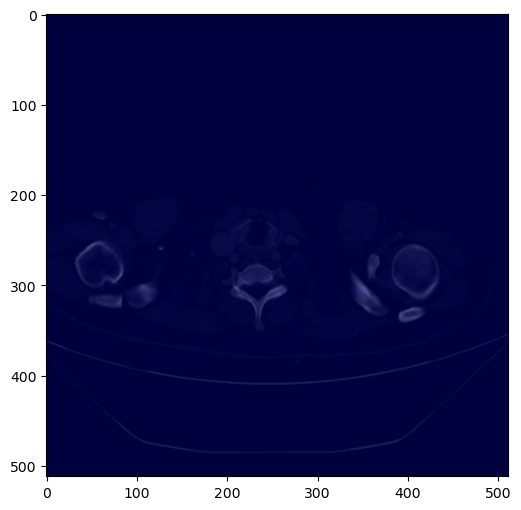

In [22]:
import numpy as np
from matplotlib.animation import FuncAnimation, PillowWriter
import matplotlib.pyplot as plt
# image , label = check_data["image"][0][0], check_data["label"][0][0]
image = sitk.GetArrayFromImage(my_nii1)
label = sitk.GetArrayFromImage(my_nii2)
H, W, D = image.shape
print(image.shape)
print(D)
# nii_norm = (nii_np - nii_np.min()) / (nii_np.max() - nii_np.min()) * 255
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(image[0, :, :], cmap='gray', vmin=0, vmax=image.max())
lbl = ax.imshow(label[0,:, :], cmap='jet', alpha=0.5, vmin=0, vmax=label.max())

def update(frame):
    im.set_data(image[frame, :, :])
    lbl.set_data(label[frame, :, :])
    return [im, lbl]


ani = FuncAnimation(fig, update, frames=132, interval=100)
ani.save("mri_animation_img3-label-mask.gif", writer=PillowWriter(fps=5))
plt.show()